# 룰 비교 실험 (FIFO / SPT / random / QSPT)
## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

load_dotenv()

BASE_DATA_PATH    = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD  = os.getenv('PM_HAZARD_THRESHOLD', '0.2')
QTIME_URGENCY_FACTOR = os.getenv('QTIME_URGENCY_FACTOR', '1.5')
os.environ['QTIME_URGENCY_FACTOR'] = str(QTIME_URGENCY_FACTOR)


##  .env 파일 MACHINE_CHOICE를 주석처리하고 실행해야 오류 안납니다.
##         # MACHINE_CHOICE=(random / FIFO / SPT / QSPT)

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

Jobs: 10 개 / Operations: 35 개 / Machines: 8 개


## 룰 비교 함수 정의

In [4]:
def _compute_qtime_violation(df_log: pd.DataFrame) -> float:
    """이벤트 로그에서 op별 대기시간이 qtime 한도를 초과한 총량을 계산."""
    qtime_map = data['operations'].set_index('op_id')['qtime']
    op_log = df_log[(df_log['resource'] == 'job') & (df_log['op_id'].notna())]
    waiting = (
        op_log[op_log['event'] == 'waiting']
        .groupby(['id', 'op_id'])['start'].min().reset_index()
        .rename(columns={'id': 'job_id', 'start': 'waiting_start'})
    )
    working = (
        op_log[op_log['event'] == 'working']
        .groupby(['id', 'op_id'])['start'].max().reset_index()
        .rename(columns={'id': 'job_id', 'start': 'working_start'})
    )
    qc = waiting.merge(working, on=['job_id', 'op_id'], how='inner')
    qc['actual_wait'] = qc['working_start'] - qc['waiting_start']
    qc['qtime_limit'] = qc['op_id'].map(qtime_map)
    qc['violation']   = (qc['actual_wait'] - qc['qtime_limit']).clip(lower=0)
    return round(qc['violation'].sum(), 3)


def run_simulation(rule: str) -> dict:
    #현재 random 상태를 사용해 룰을 한 번 실행하고 KPI를 반환 (시드는 호출부에서 설정)
    os.environ['MACHINE_CHOICE'] = rule

    _env = simpy.Environment()
    _logger = EventLogger(_env)
    _scheduler = Scheduler(
        env=_env,
        data=data,
        event_logger=_logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
        qtime_urgency_factor=float(QTIME_URGENCY_FACTOR),
    )
    _env.run(until=_scheduler.job_chk_process)

    completed, due_ok = 0, 0
    for job in _scheduler._Scheduler__jobs:
        completed += int(job.completed_time > 0.0)
        due_ok    += int(job.is_in_due_date())

    return {
        'rule':            rule,
        'makespan':        round(_env.now, 3),
        'completed_jobs':  completed,
        'due_date_met':    due_ok,
        'qtime_violation': _compute_qtime_violation(pd.DataFrame(_logger.logs)), #코드가 너무길어져서 위에 따로 함수 설정
    }


RULES = ['FIFO', 'SPT', 'random', 'QSPT']

## 시드 고정 룰 비교

In [5]:
SEED = 42

rows_p1 = []
for rule in RULES:
    random.seed(SEED)  # 룰마다 동일한 random state로 시작
    rows_p1.append(run_simulation(rule))

df_p1 = pd.DataFrame(rows_p1)
print(f"시드 고정({SEED}) 룰 비교")
display(df_p1)

시드 고정(42) 룰 비교


,rule,makespan,completed_jobs,due_date_met,qtime_violation
0,FIFO,128,10,10,54.000
1,SPT,147,10,10,153.000
2,random,159,10,10,183.161
3,QSPT,142,10,10,63.000


## 룰별 N회 시뮬레이션 평균 비교

In [6]:
N_RUNS = 100   # 시뮬레이션 횟수
N_SEED   = 2024  # 룰 간 동일 시드셋 사용

random.seed(N_SEED)
seeds_p2 = [random.randint(0, 10**9) for _ in range(N_RUNS)]

rows_p2 = []
for rule in RULES:
    for i, seed in enumerate(seeds_p2):
        random.seed(seed)
        row = run_simulation(rule)
        row['run']  = i
        row['seed'] = seed
        rows_p2.append(row)

df_p2 = pd.DataFrame(rows_p2)
print(f"총 시뮬레이션 횟수: {len(df_p2)} (룰 {len(RULES)}개 × {N_RUNS}회)")

총 시뮬레이션 횟수: 400 (룰 4개 × 100회)


In [7]:
df_stats = df_p2.groupby('rule')[['makespan', 'qtime_violation', 'completed_jobs', 'due_date_met']].agg(['mean', 'std', 'min', 'max']).round(2)
print(f"룰별 KPI 통계 (N={N_RUNS})")
display(df_stats)

룰별 KPI 통계 (N=100)


makespan                        qtime_violation                        \
           mean    std     min     max            mean    std    min     max   
rule                                                                           
FIFO     164.19  18.78  134.72  221.79          145.96  68.31  33.07  366.01   
QSPT     154.45  14.09  131.00  189.69           70.24  54.98   0.00  238.78   
SPT      155.81  13.85  132.00  201.02          174.94  80.98  20.14  415.44   
random   161.98  15.21  130.00  206.88          124.70  63.43   9.76  319.73   

       completed_jobs              due_date_met                
                 mean  std min max         mean   std min max  
rule                                                           
FIFO             10.0  0.0  10  10         9.11  0.98   5  10  
QSPT             10.0  0.0  10  10         9.50  0.80   6  10  
SPT              10.0  0.0  10  10         9.33  0.92   6  10  
random           10.0  0.0  10  10         9.04  0.97   6  10

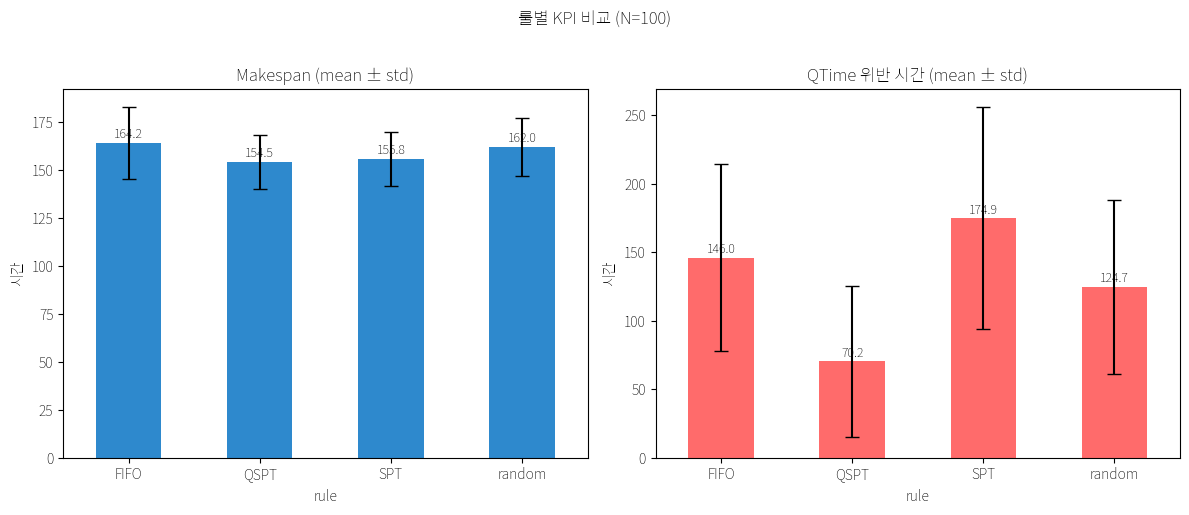

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, color, title in [
    (axes[0], 'makespan',        '#2E89CD', 'Makespan (mean ± std)'),
    (axes[1], 'qtime_violation', '#FF6B6B', 'QTime 위반 시간 (mean ± std)'),
]:
    means = df_p2.groupby('rule')[col].mean()
    stds  = df_p2.groupby('rule')[col].std()
    means.plot(kind='bar', ax=ax, color=color, rot=0, yerr=stds, capsize=5)
    ax.set_title(title)
    ax.set_ylabel('시간')
    for bar in ax.patches[:len(means)]:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'룰별 KPI 비교 (N={N_RUNS})', y=1.02)
plt.tight_layout()
plt.show()

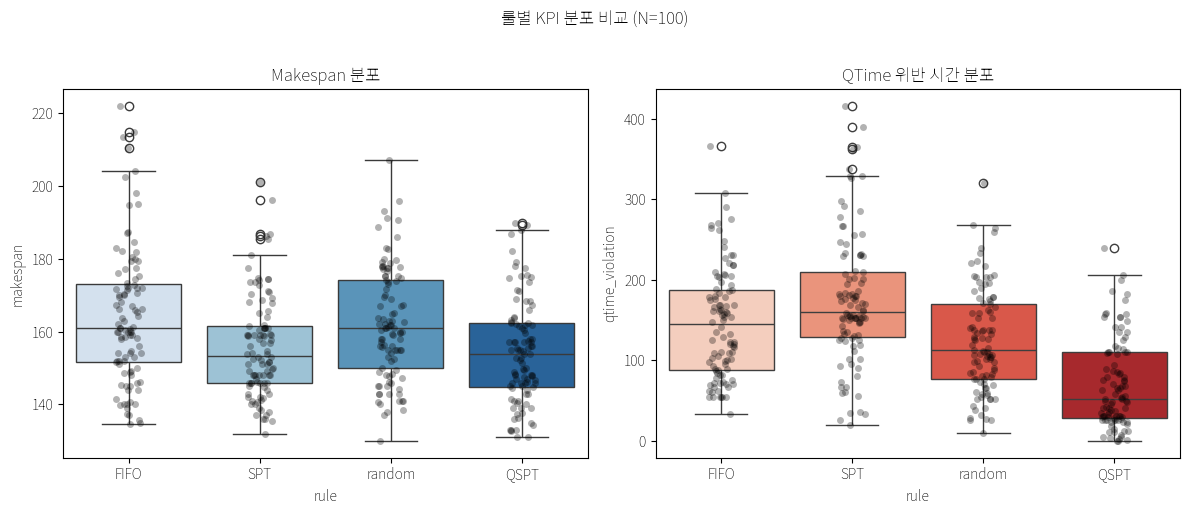

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_p2, x='rule', y='makespan',        hue='rule', legend=False, ax=axes[0], palette='Blues')
sns.boxplot(data=df_p2, x='rule', y='qtime_violation', hue='rule', legend=False, ax=axes[1], palette='Reds')
sns.stripplot(data=df_p2, x='rule', y='makespan',        ax=axes[0], color='black', alpha=0.3, jitter=True)
sns.stripplot(data=df_p2, x='rule', y='qtime_violation', ax=axes[1], color='black', alpha=0.3, jitter=True)

axes[0].set_title('Makespan 분포')
axes[1].set_title('QTime 위반 시간 분포')
plt.suptitle(f'룰별 KPI 분포 비교 (N={N_RUNS})', y=1.02)
plt.tight_layout()
plt.show()